# OMAMA → Mammo-CLIP Full Dataset Conversion

Notebook to convert the full balanced OMAMA NPZ splits into PNGs and build Mammo-CLIP CSV metadata. Run after activating the `mammo_clip` conda environment.


In [1]:
from pathlib import Path
import random
import json

import numpy as np
import pandas as pd
from PIL import Image

SCRATCH_ROOT = Path("/hpcstor6/scratch01/a/a.kanamarlapudi001")
DATA_ROOT = SCRATCH_ROOT / "mammo-clip" / "test_balanced"
IMAGES_DIR = DATA_ROOT / "images"
METADATA_DIR = DATA_ROOT / "metadata"
SPLITS_DIR = DATA_ROOT / "splits"

OUTPUT_ROOT = SCRATCH_ROOT / "mammo-clip" / "data" / "omama_balanced"
PNG_ROOT = OUTPUT_ROOT / "images_png"
CSV_ROOT = OUTPUT_ROOT / "csv"

PNG_ROOT.mkdir(parents=True, exist_ok=True)
CSV_ROOT.mkdir(parents=True, exist_ok=True)



## Sample Selection

Adjust `TOTAL_IMAGES` or `CANCER_RATIO` to control subset size and balance.


In [2]:
def load_split_ids(split_name: str):
    split_file = SPLITS_DIR / f"{split_name}_files.json"
    with split_file.open() as f:
        return json.load(f)

split_ids = {
    "train": load_split_ids("train"),
    "validation": load_split_ids("validation"),
    "test": load_split_ids("test"),
}

{split: len(ids) for split, ids in split_ids.items()}


{'train': 9284, 'validation': 1161, 'test': 1161}

## NPZ → PNG Conversion

Create subfolders by patient, write PNGs, and collect CSV rows.


In [3]:
records = []
missing_files = []

for split, ids in split_ids.items():
    for uid in ids:
        npz_path = IMAGES_DIR / f"{uid}.npz"
        meta_path = METADATA_DIR / f"{uid}.json"
        if not npz_path.exists() or not meta_path.exists():
            missing_files.append((split, uid, npz_path.exists(), meta_path.exists()))
            continue

        with meta_path.open() as f:
            meta = json.load(f)

        label = meta.get("label")
        if label is None:
            missing_files.append((split, uid, "missing_label"))
            continue

        npz_file = np.load(npz_path)
        if "arr" in npz_file:
            arr = npz_file["arr"]
        else:
            first_key = list(npz_file.keys())[0]
            arr = npz_file[first_key]

        arr = arr.astype(np.float32)
        arr -= arr.min()
        max_val = arr.max() if arr.max() > 0 else 1.0
        arr /= max_val
        arr = (arr * 255).astype(np.uint8)

        patient = meta.get("PatientID") or "unknown"
        patient_dir = PNG_ROOT / patient
        patient_dir.mkdir(parents=True, exist_ok=True)

        png_path = patient_dir / f"{uid}.png"
        Image.fromarray(arr).save(png_path)

        records.append({
            "split": split,
            "patient_id": patient,
            "image_id": uid,
            "label": label,
            "png_path": png_path,
            "npz_path": npz_path,
            "meta_path": meta_path,
            "view": meta.get("View"),
            "laterality": meta.get("ImageLaterality"),
        })

len(records), len(missing_files)


(11606, 0)

In [4]:
missing_files[:5] if missing_files else "No missing files"


'No missing files'

## Build Mammo-CLIP CSV

Create a CSV with columns expected by `train_classifier.py` (`patient_id`, `image_id`, `fold`, `cancer`, etc.).


In [5]:
df = pd.DataFrame(records)

label_map = {
    "IndexCancer": 1,
    "indexcancer": 1,
    "Cancer": 1,
    "NonCancer": 0,
    "noncancer": 0,
}

df["cancer"] = df["label"].map(label_map)

columns = [
    "patient_id",
    "image_id",
    "cancer",
    "png_path",
    "npz_path",
    "meta_path",
    "label",
    "view",
    "laterality",
]

csv_paths = {}
for split, group in df.groupby("split"):
    out_df = group[columns].copy()
    csv_path = CSV_ROOT / f"omama_{split}.csv"
    out_df.to_csv(csv_path, index=False)
    csv_paths[split] = csv_path

trainval = df[df["split"].isin(["train", "validation"])]
trainval = trainval.copy()
trainval["fold"] = trainval["split"].map({"validation": 0, "train": 1})
trainval_out = trainval[[
    "patient_id",
    "image_id",
    "cancer",
    "fold",
    "png_path",
    "npz_path",
    "meta_path",
    "label",
    "view",
    "laterality",
]]
trainval_csv = CSV_ROOT / "omama_trainval.csv"
trainval_out.to_csv(trainval_csv, index=False)

csv_paths["trainval"] = trainval_csv
csv_paths


{'test': PosixPath('/hpcstor6/scratch01/a/a.kanamarlapudi001/mammo-clip/data/omama_balanced/csv/omama_test.csv'),
 'train': PosixPath('/hpcstor6/scratch01/a/a.kanamarlapudi001/mammo-clip/data/omama_balanced/csv/omama_train.csv'),
 'validation': PosixPath('/hpcstor6/scratch01/a/a.kanamarlapudi001/mammo-clip/data/omama_balanced/csv/omama_validation.csv'),
 'trainval': PosixPath('/hpcstor6/scratch01/a/a.kanamarlapudi001/mammo-clip/data/omama_balanced/csv/omama_trainval.csv')}

## Quality Check: NPZ vs PNG

Plot a few random samples to verify the PNG matches the original array.


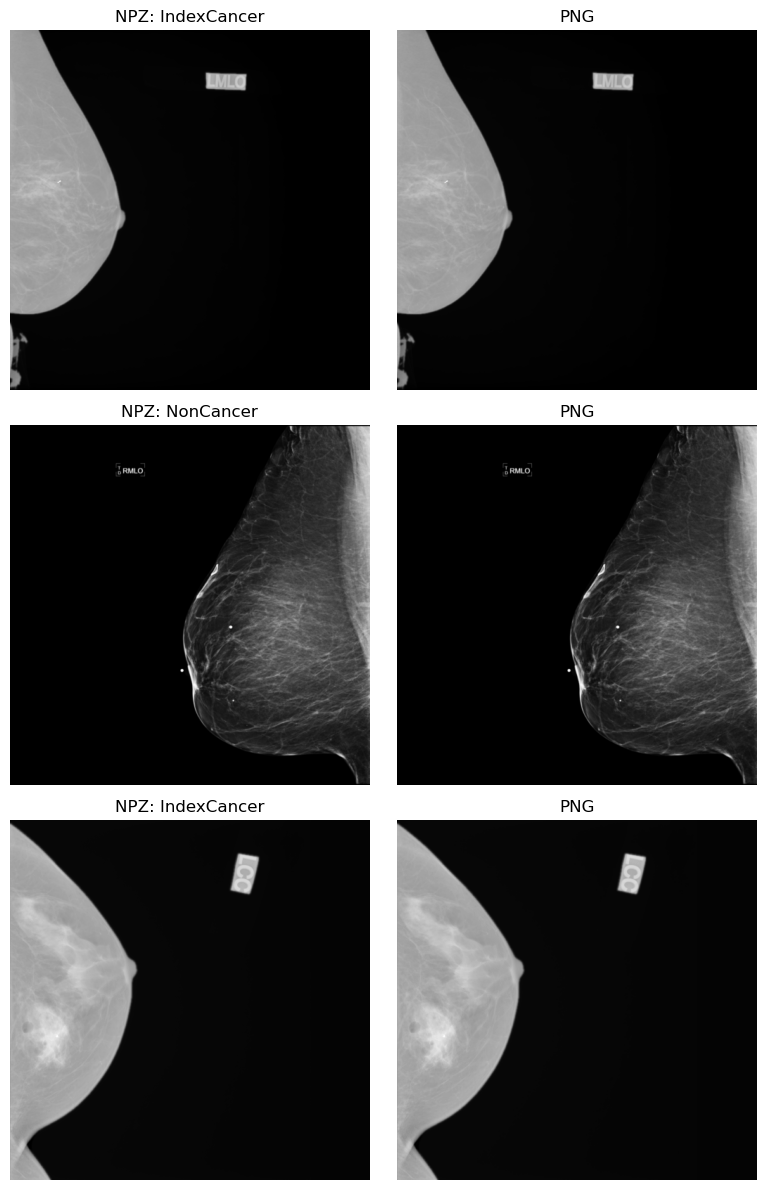

In [6]:
import matplotlib.pyplot as plt

SAMPLES_TO_SHOW = 3
sample_rows = random.sample(records, min(SAMPLES_TO_SHOW, len(records)))

fig, axes = plt.subplots(len(sample_rows), 2, figsize=(8, 4 * len(sample_rows)))
if len(sample_rows) == 1:
    axes = np.expand_dims(axes, axis=0)

for ax_row, item in zip(axes, sample_rows):
    npz = np.load(item["npz_path"])
    arr_npz = npz["arr"] if "arr" in npz else npz[list(npz.keys())[0]]
    arr_png = np.array(Image.open(item["png_path"]))

    ax_row[0].imshow(arr_npz, cmap="gray")
    ax_row[0].set_title(f"NPZ: {item['label']}")
    ax_row[0].axis("off")

    ax_row[1].imshow(arr_png, cmap="gray")
    ax_row[1].set_title("PNG")
    ax_row[1].axis("off")

plt.tight_layout()
plt.show()



## Summary

Check CSV, count class balance.


In [7]:
df.groupby("split")["cancer"].value_counts(), len(df)


(split       cancer
 test        1          588
             0          573
 train       0         4644
             1         4640
 validation  0          586
             1          575
 Name: count, dtype: int64,
 11606)